# Ajuste final y evaluación

`03_modeling.ipynb` eligió XGBoost sin reponderar las clases —sin `scale_pos_weight` ni remuestreo, algo
que ahí se midió antes que suponerse— y con el umbral 0,2: **+128.701** sobre aprobar todo en
los cuatro bloques de validación, contra **+23.999** de la mejor regla de un corte sobre `score`. Quedan
dos cosas:

1. **Buscar hiperparámetros**, que hasta acá corrieron en una configuración razonable pero sin ajustar.
2. **Disparar una sola vez** contra los 9 días reservados desde el 13 de abril.

El orden importa y no es reversible: el período reservado se usa **al final, una vez, con el modelo ya
elegido**. Si se lo mirara antes, cualquier decisión posterior lo convertiría en otro conjunto de
validación y el número final dejaría de significar lo que dice significar.

## 1. La búsqueda: qué se optimiza y con qué

**Qué se optimiza: pesos.** El objetivo es la ganancia sobre aprobar todo, sumada en los cuatro folds,
con el umbral 0,2. No el AUC. La sección 2 de `03_modeling.ipynb` mostró por qué importa la distinción:
entre la logística y XGBoost hay 0,04 de AUC y apenas un 1% de diferencia en plata. Optimizar AUC sería
optimizar una métrica que se correlaciona con el objetivo pero no es el objetivo.

**Con qué se valida: los mismos folds temporales** de `temporal_folds`, con el mismo `N_SPLITS`. Un
`KFold` aleatorio dejaría entrenar con transacciones posteriores a las de validación.

**Por qué Optuna y no una grilla.** El espacio tiene ocho dimensiones, la mayoría continuas. Una grilla
de apenas tres valores por dimensión son 6.561 combinaciones, y a unos cinco segundos cada una no
termina nunca. Optuna aporta dos cosas concretas:

- **TPE** en lugar de azar: modela qué regiones del espacio vinieron dando buenos resultados y muestrea
  ahí, en vez de probar a ciegas como `RandomizedSearchCV`.
- **Pruning**: como la ganancia se acumula fold por fold, una prueba que arranca mal se corta después del
  primer fold en vez de gastar los cuatro.

**Hipótesis, y es la que importa para el informe.** La búsqueda va a mejorar la ganancia en validación
—siempre lo hace: es un máximo sobre 40 intentos—, pero **poco de esa mejora va a sobrevivir fuera de
muestra**. Es el mismo mecanismo que con el umbral en `03`: elegir mirando los mismos cuatro folds donde
después se reporta convierte parte del ruido en ganancia aparente. Si la hipótesis es correcta, la
ventaja del modelo ajustado sobre el de defecto tiene que encogerse bastante en el holdout.

In [1]:
import time
from pathlib import Path

import joblib
import numpy as np
import optuna
import pandas as pd
import shap
from matplotlib import pyplot as plt
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

from fraud_detection.constants import DATE, N_SPLITS, RANDOM_STATE, TARGET
from fraud_detection.dataset import load_transactions, normalize_text, split_development
from fraud_detection.evaluation import (
    expected_gain,
    gain_by_policy,
    optimal_probability_threshold,
    sweep_gain,
)
from fraud_detection.features import build_preprocessor
from fraud_detection.modeling import temporal_folds
from fraud_detection.plots import PALETTE

optuna.logging.set_verbosity(optuna.logging.WARNING)

development, test = split_development(normalize_text(load_transactions()))
X, y = development.drop(columns=[TARGET]), development[TARGET]
folds = list(temporal_folds(development[DATE], n_splits=N_SPLITS))
UMBRAL = optimal_probability_threshold()
GRILLA = np.round(np.arange(0.02, 0.62, 0.01), 2)
NOMBRES = [f"fold {numero}" for numero in range(len(folds))]

BASE = dict(tree_method="hist", eval_metric="aucpr", n_jobs=-1, random_state=RANDOM_STATE)
DEFECTO = dict(
    n_estimators=500, learning_rate=0.05, max_depth=5, subsample=0.8, colsample_bytree=0.8, **BASE
)


def modelo_xgb(parametros: dict) -> Pipeline:
    """Pipeline completo con los hiperparámetros dados."""
    return Pipeline(
        [("preprocesamiento", build_preprocessor()), ("modelo", XGBClassifier(**parametros))]
    )


def ganancia_en_folds(parametros: dict, trial=None) -> float:
    """Ganancia sobre aprobar todo, sumada en los folds temporales."""
    total = 0.0
    for numero, (train_pos, valid_pos) in enumerate(folds):
        pipeline = modelo_xgb(parametros).fit(X.iloc[train_pos], y.iloc[train_pos])
        valid = development.iloc[valid_pos]
        probabilidad = pd.Series(pipeline.predict_proba(X.iloc[valid_pos])[:, 1], index=valid.index)
        piso = expected_gain(valid, pd.Series(True, index=valid.index))
        total += expected_gain(valid, probabilidad.lt(UMBRAL)) - piso
        if trial is not None:
            trial.report(total, numero)
            if trial.should_prune():
                raise optuna.TrialPruned()
    return total


def objetivo(trial) -> float:
    """Espacio de búsqueda de XGBoost, evaluado en ganancia."""
    return ganancia_en_folds(
        dict(
            n_estimators=trial.suggest_int("n_estimators", 200, 900, step=100),
            learning_rate=trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
            max_depth=trial.suggest_int("max_depth", 3, 8),
            min_child_weight=trial.suggest_int("min_child_weight", 1, 20, log=True),
            subsample=trial.suggest_float("subsample", 0.6, 1.0),
            colsample_bytree=trial.suggest_float("colsample_bytree", 0.5, 1.0),
            reg_lambda=trial.suggest_float("reg_lambda", 0.01, 10.0, log=True),
            gamma=trial.suggest_float("gamma", 0.0, 5.0),
            **BASE,
        ),
        trial=trial,
    )


inicio = time.time()
estudio = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=8, n_warmup_steps=1),
)
estudio.optimize(objetivo, n_trials=40)

podadas = sum(prueba.state == optuna.trial.TrialState.PRUNED for prueba in estudio.trials)
ganancia_defecto = ganancia_en_folds(DEFECTO)
print(f"{len(estudio.trials)} pruebas en {time.time() - inicio:.0f}s, {podadas} podadas")
print(f"defecto:  {ganancia_defecto:,.0f}")
print(f"ajustado: {estudio.best_value:,.0f}  ({estudio.best_value - ganancia_defecto:+,.0f})")
display(pd.Series(estudio.best_params).to_frame("mejor valor"))

40 pruebas en 91s, 21 podadas
defecto:  128,701
ajustado: 133,828  (+5,127)


,mejor valor
n_estimators,400.000000
learning_rate,0.123289
max_depth,3.000000
min_child_weight,1.000000
subsample,0.869562
colsample_bytree,0.668390
reg_lambda,0.032014
gamma,1.486420


**Lectura: la búsqueda mejora, y el pruning hace que salga barata.**

De las 40 pruebas, **21 se podaron** después del primer o segundo fold, así que el costo real fue
bastante menor que 40 ajustes completos. La mejor configuración rinde **+133.828** contra los +128.701
del modelo de defecto: **+5.127**, un 4% más.

El sentido del ajuste es informativo: la búsqueda se fue hacia **menos capacidad y más regularización
por árbol** —`max_depth` 3 en vez de 5, `gamma` 1,49, 400 árboles con un `learning_rate` más alto—, que
es hacia dónde suele ir cuando los bloques de entrenamiento son cortos. El fold 0 entrena con 8 días.

Eso sí, +5.127 elegidos sobre los mismos cuatro folds donde se los mide no son +5.127 comprobados.

## 2. ¿La mejora es pareja entre folds?

Antes del holdout hay una pregunta barata de responder. Si el ajuste captó algo real del problema,
tendría que mejorar en **todos** los folds. Si mejora mucho en uno y empeora en otro, lo que capturó es
la particularidad de un período.

In [2]:
comparacion = []
for numero, (train_pos, valid_pos) in enumerate(folds):
    valid = development.iloc[valid_pos]
    piso = expected_gain(valid, pd.Series(True, index=valid.index))
    fila = {}
    for nombre, parametros in [("defecto", DEFECTO), ("ajustado", {**estudio.best_params, **BASE})]:
        pipeline = modelo_xgb(parametros).fit(X.iloc[train_pos], y.iloc[train_pos])
        probabilidad = pd.Series(pipeline.predict_proba(X.iloc[valid_pos])[:, 1], index=valid.index)
        fila[f"g_{nombre}"] = expected_gain(valid, probabilidad.lt(UMBRAL)) - piso
        fila[f"auc_{nombre}"] = roc_auc_score(valid[TARGET], probabilidad)
    fila["diferencia"] = fila["g_ajustado"] - fila["g_defecto"]
    comparacion.append(fila)

comparacion = pd.DataFrame(comparacion, index=NOMBRES)
comparacion.loc["total"] = comparacion.sum()
comparacion.loc["total", ["auc_defecto", "auc_ajustado"]] = np.nan
display(comparacion.round(4))

,g_defecto,auc_defecto,g_ajustado,auc_ajustado,diferencia
fold 0,27765.885,0.8795,29986.7225,0.8824,2220.8375
fold 1,30049.290,0.8840,33345.8750,0.8848,3296.5850
fold 2,32131.810,0.8819,31493.4000,0.8855,-638.4100
fold 3,38754.155,0.8885,39002.2525,0.8874,248.0975
total,128701.140,NaN,133828.2500,NaN,5127.1100


**Lectura: mejora en tres de cuatro, no en los cuatro.**

Los folds 0, 1 y 3 mejoran —**+2.221**, **+3.297** y **+248**— y el fold 2 **empeora 638**. La mejora
tampoco se reparte: entre los folds 0 y 1 suman 5.517 de los 5.127 netos, y el fold 3 aporta 248.

Hay un detalle que refuerza lo que ya venía apareciendo: en el fold 2 el modelo ajustado tiene **mejor
AUC** (0,8855 contra 0,8819) y aun así **pierde plata**. Ordena mejor y decide peor, porque la decisión
se toma con un único corte.

Nada de esto alcanza para descartar el ajuste —el saldo es positivo y el AUC mejora en tres de los
cuatro folds—, pero sí para desconfiar del tamaño de la mejora, que es lo que predecía la hipótesis.
**El holdout es la única medición que lo resuelve.**

**Se declara antes de mirar:** el modelo que va al período reservado es el **ajustado**. El de defecto se
reporta al lado como referencia, no como una alternativa a elegir después de ver los resultados.

## 3. El disparo final

Los modelos se entrenan con **todo** desarrollo y se aplican una única vez sobre los 9 días reservados,
con el umbral 0,2 y el corte de `score` que ganó en desarrollo.

Van tres variantes a la tabla, y la tercera no es decorativa. **`score` sigue sin confirmarse como dato
disponible al momento de decidir el pago**, y es la feature más importante del modelo. Si resultara
calcularse después de conocer el resultado de la transacción, sería una fuga y el número válido sería el
de la variante **sin `score`**. Reportar las dos deja el resultado a salvo de esa respuesta.

**Hipótesis.** La ganancia sobre aprobar todo tendría que ser del mismo orden que en validación una vez
ajustada por tamaño del período, y **la ventaja del ajustado sobre el de defecto tendría que encogerse
respecto de los +5.127** de la sección 1. Sacar `score` debería costar algo parecido al 15% que costó en
los folds, no derrumbar el modelo. Si en cambio rindiera mucho menos de lo esperable, habría que
sospechar de un cambio entre períodos y no de la búsqueda.

In [3]:
sin_etiqueta = test.drop(columns=[TARGET])
corte_score = sweep_gain(development, development.score, range(0, 101)).idxmax()
politicas = {
    "aprobar todo": pd.Series(True, index=test.index),
    f"regla score < {corte_score}": test.score.lt(corte_score).fillna(False),
}

AJUSTADO = {**estudio.best_params, **BASE}
entrenados = {}
for nombre, parametros, use_score in [
    ("defecto", DEFECTO, True),
    ("ajustado", AJUSTADO, True),
    ("ajustado sin score", AJUSTADO, False),
]:
    entrenados[nombre] = Pipeline(
        [
            ("preprocesamiento", build_preprocessor(use_score=use_score)),
            ("modelo", XGBClassifier(**parametros)),
        ]
    ).fit(X, y)
    probabilidad = pd.Series(entrenados[nombre].predict_proba(sin_etiqueta)[:, 1], index=test.index)
    politicas[f"xgboost {nombre}, p < 0,2"] = probabilidad.lt(UMBRAL)
    print(
        f"{nombre:18} auc {roc_auc_score(test[TARGET], probabilidad):.4f} | "
        f"ap {average_precision_score(test[TARGET], probabilidad):.4f} | "
        f"probabilidad media {probabilidad.mean():.4f}"
    )

politicas["maximo alcanzable"] = test[TARGET].eq(0)
print(
    f"entrenados con {len(development):,} transacciones de "
    f"{development[DATE].dt.normalize().nunique()} días"
)
holdout = gain_by_policy(test, politicas)
holdout["sobre_aprobar_todo"] = holdout.ganancia - holdout.loc["aprobar todo", "ganancia"]
display(holdout.round(2))

probabilidad_final = pd.Series(
    entrenados["ajustado"].predict_proba(sin_etiqueta)[:, 1], index=test.index
)
barrido = sweep_gain(test, probabilidad_final, GRILLA)
print(
    f"{len(test):,} transacciones | {test[DATE].dt.normalize().nunique()} días | "
    f"{test[TARGET].mean():.2%} de fraude"
)
print(
    f"El mejor corte sobre este mismo período habría sido {barrido.idxmax()}, con "
    f"{barrido.max() - expected_gain(test, probabilidad_final.lt(UMBRAL)):,.0f} más que el 0,2 teórico"
)

defecto            auc 0.8889 | ap 0.4470 | probabilidad media 0.0469


ajustado           auc 0.8885 | ap 0.4450 | probabilidad media 0.0475


ajustado sin score auc 0.8468 | ap 0.3477 | probabilidad media 0.0497
entrenados con 114,506 transacciones de 36 días


,ganancia,pct_del_maximo,aprobadas,aprobadas_pct,fraudes_aprobados,sobre_aprobar_todo
aprobar todo,226254.46,65.70,35494.0,100.00,1571.0,0.00
regla score < 91,249455.56,72.44,33933.0,95.60,1066.0,23201.11
"xgboost defecto, p < 0,2",273656.99,79.46,33585.0,94.62,807.0,47402.53
"xgboost ajustado, p < 0,2",273821.35,79.51,33564.0,94.56,803.0,47566.89
"xgboost ajustado sin score, p < 0,2",264121.91,76.69,33571.0,94.58,924.0,37867.45
maximo alcanzable,344380.70,100.00,33923.0,95.57,0.0,118126.25


35,494 transacciones | 9 días | 4.43% de fraude
El mejor corte sobre este mismo período habría sido 0.19, con 728 más que el 0,2 teórico


**Lectura: el modelo rinde, y la hipótesis sobre el ajuste se confirma.**

**El modelo ajustado agrega +47.567 sobre aprobar todo, contra +23.201 de la regla de un corte sobre
`score`.** Poco más del doble. Pasa del 65,70% del máximo alcanzable al **79,51%**, y captura el **40%**
de los 118.126 que estaban en disputa. Deja pasar 803 fraudes contra los 1.571 de aprobar todo, y para
eso rechaza el 5,4% de las transacciones.

**Del ajuste sobrevivió muy poco.** En validación el modelo ajustado sacaba +5.127 al de defecto; sobre
el holdout le saca **+164**, un 3% de aquella diferencia. El AUC incluso queda un pelo por debajo
(0,8885 contra 0,8889). La hipótesis de la sección 1 era exactamente esa, y el número la confirma: la
mayor parte de esos +5.127 era ruido de selección, no aprendizaje. Vale la pena decirlo así en el
informe, porque es la respuesta directa a por qué el laboratorio y la producción pueden diferir.

**Y el umbral teórico volvió a aguantar.** Sobre el holdout el mejor corte habría sido 0,19, con
**728** más que el 0,2: un 1,5% de la ganancia. En desarrollo el óptimo de cada fold caía entre 0,12 y
0,15 y acá se movió a 0,19. El óptimo empírico cambia de período en período; el 0,2 derivado de la regla
de negocio no se mueve y nunca queda lejos. Haber ajustado el umbral a los folds habría sido perseguir
ruido, igual que con los hiperparámetros.

**Y si `score` resultara ser una fuga, el modelo sigue en pie.** Sin esa columna rinde **+37.867**, un
20% menos, con AUC 0,8468 y 924 fraudes aprobados en vez de 803. Sigue siendo **1,6 veces** la regla de
un corte sobre `score`, que sí la usa. La hipótesis apuntaba a un costo cercano al 15% que se midió en
los folds; el costo real fue algo mayor, 20%, pero del mismo orden. La respuesta del dueño del dato
cambia cuánto se gana, no si conviene el modelo.

Nada de esto se eligió mirando el test: el modelo se declaró en la sección 2 y el umbral sale de la regla
de negocio.

## 4. Qué mira el modelo

Queda una pregunta que el informe necesita y que ninguna métrica responde: **por qué el modelo rechaza
una transacción**. SHAP reparte la predicción de cada fila entre sus features, así que promediando el
valor absoluto se obtiene cuánto pesa cada una.

**Hipótesis.** Si el EDA acertó, arriba tienen que aparecer `score` y la ausencia de `o`, que era la
señal más fuerte del dataset. Y la vara para leer el resto es **`k`**, que el EDA midió como ruido
—AUC 0,5061, independiente de la etiqueta— y que se conservó justamente para esto: **toda feature que
pese menos que `k` está compitiendo con ruido puro.**

Se explica el modelo del último fold sobre su propia validación, de modo que las atribuciones sean sobre
transacciones que ese modelo no entrenó.

17 de 33 features pesan menos que el ruido:
hora_cos, h, es_madrugada, o_Y, hora_sin, a_2, a_4, a_1, missingindicator_d, missingindicator_b, a_3, p_N, missingindicator_m, missingindicator_c, missingindicator_f, missingindicator_l, p_Y


,|SHAP| medio
score,0.8657
o_Ausente,0.6790
g,0.2348
l,0.2118
o_N,0.2065
monto,0.2034
m,0.1942
f,0.1137


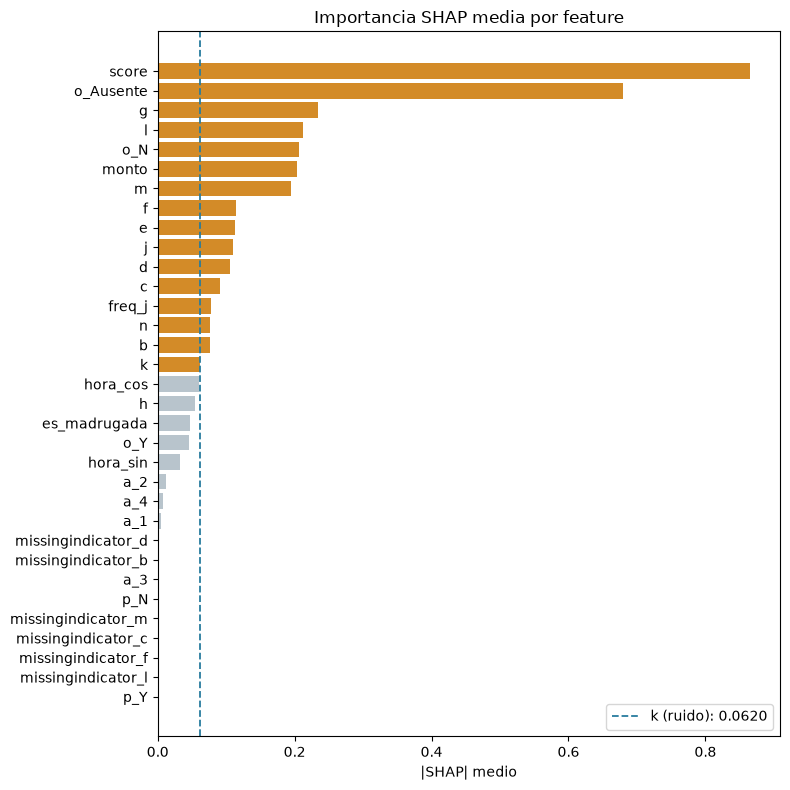

In [4]:
train_pos, valid_pos = folds[-1]
explicado = modelo_xgb({**estudio.best_params, **BASE}).fit(X.iloc[train_pos], y.iloc[train_pos])
preprocesador = explicado.named_steps["preprocesamiento"]
matriz = preprocesador.transform(X.iloc[valid_pos])
muestra = np.random.RandomState(RANDOM_STATE).choice(len(matriz), 5000, replace=False)

valores = shap.TreeExplainer(explicado.named_steps["modelo"]).shap_values(matriz[muestra])
importancia = pd.Series(
    np.abs(valores).mean(axis=0), index=preprocesador.get_feature_names_out()
).sort_values()

ruido = importancia["k"]
fig, ax = plt.subplots(figsize=(8, 8))
ax.barh(
    importancia.index,
    importancia.to_numpy(),
    color=[PALETTE["Fraude"] if valor >= ruido else "#B8C4CC" for valor in importancia],
)
ax.axvline(ruido, color="#287C9E", linestyle="--", linewidth=1.3, label=f"k (ruido): {ruido:.4f}")
ax.set(title="Importancia SHAP media por feature", xlabel="|SHAP| medio")
ax.legend()
fig.tight_layout()

print(f"{(importancia < ruido).sum()} de {len(importancia)} features pesan menos que el ruido:")
print(", ".join(reversed(importancia[importancia < ruido].index)))
display(importancia.sort_values(ascending=False).head(8).round(4).to_frame("|SHAP| medio"))

**Lectura: el EDA se sostiene y la variable de control hace su trabajo.**

`score` encabeza con holgura y **`o_Ausente` queda segundo**: la ausencia de `o`, que el EDA identificó
como la señal más fuerte, sobrevive a todo el preprocesamiento y es lo segundo que más mueve al modelo.
Después vienen `g`, `l`, `o_N` y `monto`.

Debajo de la línea de `k` quedan **17 de las 33 features**: los seis indicadores de nulo, las cuatro
categorías de `a`, `p_N`, `p_Y`, `o_Y`, `h` y **las tres features temporales**. Que pesen menos que una
variable uniforme e independiente de la etiqueta las vuelve candidatas a poda.

Tres advertencias antes de podar nada:

- **El promedio castiga a las features que afectan a pocas filas.** `es_madrugada` vale para el 3,8% de
  las transacciones, así que promediar su SHAP sobre todas las filas la diluye por construcción. El EDA
  midió que ahí el fraude es 11,59% contra 4,93%: el efecto es real y sigue estando. Para señales raras y
  fuertes hay que mirar el SHAP en el subconjunto donde aplican, no la media global.
- **`k` no es un umbral mágico.** Es una medición ruidosa más; una feature apenas por debajo puede
  aportar algo real en otro período.
- **La poda hay que medirla, no deducirla.** Sacar features y comparar ganancia sobre los mismos folds,
  con la misma disciplina que todo lo demás. Y no se puede decidir con este gráfico y validar con el
  holdout, que ya se usó.

In [5]:
ARTEFACTOS = Path("../models")
ARTEFACTOS.mkdir(exist_ok=True)
destino = ARTEFACTOS / "xgboost_ajustado.joblib"
joblib.dump(
    {
        "pipeline": entrenados["ajustado"],
        "umbral": UMBRAL,
        "parametros": {**estudio.best_params, **BASE},
        "entrenado_hasta": development[DATE].max(),
    },
    destino,
)

recuperado = joblib.load(destino)
np.testing.assert_allclose(
    recuperado["pipeline"].predict_proba(sin_etiqueta)[:, 1], probabilidad_final.to_numpy()
)
print(
    f"{destino} | {destino.stat().st_size / 1e6:.1f} MB | " f"reproduce las mismas probabilidades"
)

../models/xgboost_ajustado.joblib | 1.0 MB | reproduce las mismas probabilidades


## Conclusión

**El modelo final es XGBoost con los hiperparámetros de la sección 1, sin reponderar las clases y con el
umbral 0,2 derivado de la regla de negocio.** Sobre los 9 días reservados agrega **+47.567** contra aprobar todo y
**+24.366** contra la regla de un corte sobre `score`, que es la política de referencia. Si `score`
resultara no estar disponible al decidir el pago, la cifra válida es **+37.867**, que sigue siendo 1,6
veces esa referencia.

Lo que se guarda es el **Pipeline entrenado**, no una tabla de features: ahí adentro viajan la
imputación, el one-hot, el target encoding y la codificación por frecuencia, todos ajustados con datos
de entrenamiento. Es la misma decisión que `02_feature_engineering.ipynb` verificó con cuatro chequeos, y
es lo que hace que el modelo pueda aplicarse a una transacción nueva sin recalcular nada del histórico.

Tres resultados que valen para el informe tanto como el número final:

- **La distancia entre familias de modelos fue del 1%**, según midió `03`, y la del ajuste de
  hiperparámetros, +164 sobre datos nuevos. El trabajo que movió la aguja fue entender la economía del problema y construir features
  a partir del EDA, no la elección del algoritmo.
- **Todo argmax sobre validación exagera.** Pasó con el corte de `score` en el EDA, con el umbral en
  `03` y con los hiperparámetros acá. Es la razón principal por la que un número de laboratorio puede no
  reproducirse en producción.
- **Nada de esto vale sin la disciplina temporal.** El período reservado se usó una sola vez, al final,
  con el modelo ya declarado.

**Lo que queda pendiente son dos cosas**, las dos medibles con lo que ya está armado:

- **Desempeño por país.** El modelo es global y, según el EDA, BR aporta 4.880 de los 5.929 fraudes de
  desarrollo. Falta verificar que AR no quede peor servida, midiendo ganancia y recall por país sobre los
  mismos períodos y reportando el soporte de cada uno.
- **La poda de las 17 features que quedaron por debajo de `k`.** Hay que medirla sobre los folds, no
  deducirla del gráfico, y teniendo en cuenta que el promedio castiga a las señales que afectan a pocas
  filas.